# Retail Demand Forecasting using Machine Learning

## Notebook 5

# Random Forest Regression

---

### Objectives

- Load Dataset
- Data Preparation
- Train Random Forest Regressor
- Evaluate Performance
- Feature Importance
- Save Model

In [2]:
# ==============================================================================
# INSTALL REQUIRED LIBRARIES
# ==============================================================================

# Uncomment if required

# %pip install scikit-learn
# %pip install joblib
# %pip install matplotlib
# %pip install seaborn

In [18]:
# ==============================================================================
# IMPORT LIBRARIES
# ==============================================================================

import warnings
warnings.filterwarnings("ignore")

import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [19]:
# ==============================================================================
# DISPLAY SETTINGS
# ==============================================================================

plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

In [20]:
# ==============================================================================
# LOAD DATASET
# ==============================================================================

df = pd.read_csv(r"C:\Users\asus\Desktop\RETAIL\dataset\retail_cleaned.csv")

print(df.shape)

(8601, 33)


In [21]:
# ==============================================================================
# FIRST FIVE RECORDS
# ==============================================================================

df.head()

,Date,Store_ID,Product_ID,Category,Region,Holiday,Promotion,Weather,Temperature,Fuel_Price,CPI,Unemployment,Inventory,Price,Competitor_Price,Discount,Customers,Sales,Year,Month,Day,Week,Quarter,Day_Name,Month_Name,Weekend,Season,Inventory_Per_Customer,Price_Difference,Discount_Amount,Final_Price,Sales_Per_Customer,Promotion_Impact
0,2023-01-01,41,1029,2,0,0,0,2,32.1,107.07,287.06,3.78,452,111.98,102.88,14,278,27,2023,1,1,52,1,3,4,1,3,1.620072,9.10,15.6772,96.3028,0.096774,0
1,2023-01-02,46,1167,5,3,0,1,0,18.3,114.77,271.06,4.44,452,713.49,664.33,48,192,54,2023,1,2,1,1,1,4,0,3,2.341969,49.16,342.4752,371.0148,0.279793,48
2,2023-01-03,7,1024,3,1,1,1,0,17.9,81.74,235.13,4.12,964,788.14,796.34,40,336,146,2023,1,3,1,1,5,4,0,3,2.860534,-8.20,315.2560,472.8840,0.433234,40
3,2023-01-04,13,1181,2,1,0,1,2,35.7,114.66,225.62,7.08,874,761.42,741.65,13,363,135,2023,1,4,1,1,6,4,0,3,2.401099,19.77,98.9846,662.4354,0.370879,13
4,2023-01-05,18,1180,5,1,0,0,2,23.9,90.80,291.05,9.19,244,1385.00,1479.97,49,48,0,2023,1,5,1,1,4,4,0,3,4.979592,-94.97,678.6500,706.3500,0.000000,0


In [22]:
# ==============================================================================
# CHECK MISSING VALUES
# ==============================================================================

df.isnull().sum()

Date                      0
Store_ID                  0
Product_ID                0
Category                  0
Region                    0
Holiday                   0
Promotion                 0
Weather                   0
Temperature               0
Fuel_Price                0
CPI                       0
Unemployment              0
Inventory                 0
Price                     0
Competitor_Price          0
Discount                  0
Customers                 0
Sales                     0
Year                      0
Month                     0
Day                       0
Week                      0
Quarter                   0
Day_Name                  0
Month_Name                0
Weekend                   0
Season                    0
Inventory_Per_Customer    0
Price_Difference          0
Discount_Amount           0
Final_Price               0
Sales_Per_Customer        0
Promotion_Impact          0
dtype: int64

In [23]:
# ==============================================================================
# DEFINE TARGET VARIABLE
# ==============================================================================

TARGET = "Sales"

In [24]:
# ==============================================================================
# INPUT AND OUTPUT FEATURES
# ==============================================================================

X = df.drop(columns=[TARGET])

y = df[TARGET]

In [25]:
# ==============================================================================
# REMOVE DATE COLUMN IF PRESENT
# ==============================================================================

if "Date" in X.columns:
    X = X.drop(columns=["Date"])

# Remove target leakage feature if present
if "Sales_Per_Customer" in X.columns:
    X = X.drop(columns=["Sales_Per_Customer"])

print(X.shape)

(8601, 30)


In [26]:
# ==============================================================================
# LABEL ENCODING
# ==============================================================================

encoder = LabelEncoder()

for col in X.select_dtypes(include="object").columns:
    X[col] = encoder.fit_transform(X[col])

print("Encoding Completed")

Encoding Completed


In [27]:
# ==============================================================================
# TRAIN TEST SPLIT
# ==============================================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42

)

print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

Training Shape : (6880, 30)
Testing Shape : (1721, 30)


In [28]:
# ==============================================================================
# CREATE RANDOM FOREST MODEL
# ==============================================================================

rf_model = RandomForestRegressor(

    n_estimators=300,

    max_depth=15,

    min_samples_split=5,

    min_samples_leaf=2,

    random_state=42,

    n_jobs=-1

)

In [29]:
# ==============================================================================
# TRAIN MODEL
# ==============================================================================

rf_model.fit(

    X_train,

    y_train

)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [37]:
# ==============================================================================
# CREATE PREDICTIONS
# ==============================================================================

y_train_pred = rf_model.predict(X_train)

y_test_pred = rf_model.predict(X_test)

print("Predictions Created Successfully")

Predictions Created Successfully


In [38]:
# ==============================================================================
# MODEL EVALUATION
# ==============================================================================

mae = mean_absolute_error(y_test, y_test_pred)

mse = mean_squared_error(y_test, y_test_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_test_pred)

print("MAE :", round(mae,2))
print("MSE :", round(mse,2))
print("RMSE :", round(rmse,2))
print("R² :", round(r2,4))

MAE : 8.24
MSE : 108.11
RMSE : 10.4
R² : 0.962


In [39]:
# ==============================================================================
# PERFORMANCE TABLE
# ==============================================================================

performance = pd.DataFrame({

    "Metric":["MAE","MSE","RMSE","R²"],

    "Value":[mae,mse,rmse,r2]

})

performance

,Metric,Value
0,MAE,8.238595
1,MSE,108.111696
2,RMSE,10.397677
3,R²,0.962015


In [40]:
# ==============================================================================
# ACTUAL VS PREDICTED
# ==============================================================================

prediction_df = pd.DataFrame({

    "Actual":y_test,

    "Predicted":y_test_pred,

    "Error":y_test-y_test_pred

})

prediction_df.head(20)

,Actual,Predicted,Error
5839,6,7.791247,-1.791247
4275,91,93.429112,-2.429112
6086,49,45.261207,3.738793
8265,90,90.138854,-0.138854
5493,15,22.000146,-7.000146
1688,127,111.240148,15.759852
5241,59,50.417251,8.582749
221,53,64.196802,-11.196802
239,63,64.554500,-1.554500
2208,53,57.408622,-4.408622


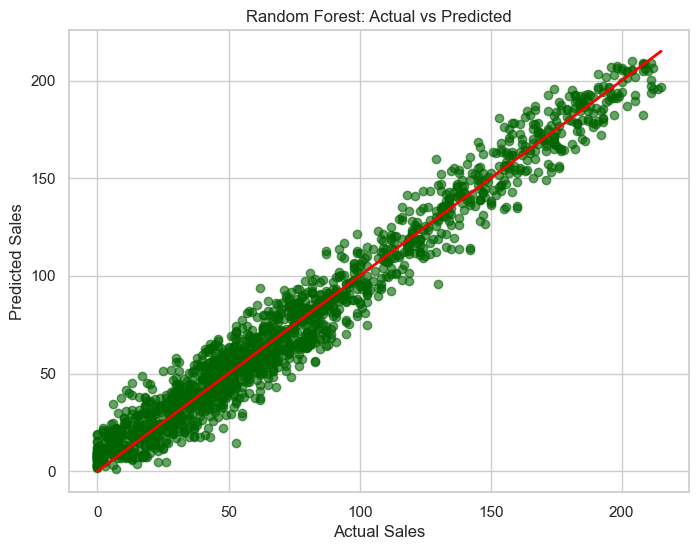

In [41]:
# ==============================================================================
# ACTUAL VS PREDICTED SCATTER
# ==============================================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.6,
    color="darkgreen"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

In [42]:
# ==============================================================================
# TRAINING R² SCORE
# ==============================================================================

train_r2 = r2_score(y_train, y_train_pred)

print("Training R² Score :", round(train_r2,4))

Training R² Score : 0.9931


In [44]:
# ==============================================================================
# TESTING R² SCORE
# ==============================================================================

test_r2 = r2_score(y_test, y_test_pred)

print("Testing R² Score :", round(test_r2,4))

Testing R² Score : 0.962


In [45]:
# ==============================================================================
# ADJUSTED R² SCORE
# ==============================================================================

n = X_test.shape[0]

p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - test_r2) * (n - 1) / (n - p - 1))

print("Adjusted R² :", round(adjusted_r2,4))

Adjusted R² : 0.9613


In [46]:
# ==============================================================================
# MEAN ABSOLUTE PERCENTAGE ERROR (MAPE)
# ==============================================================================

mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

print("MAPE :", round(mape,2), "%")

MAPE : inf %


In [47]:
# ==============================================================================
# RESIDUALS
# ==============================================================================

residuals = y_test - y_test_pred

residuals.head()

5839   -1.791247
4275   -2.429112
6086    3.738793
8265   -0.138854
5493   -7.000146
Name: Sales, dtype: float64

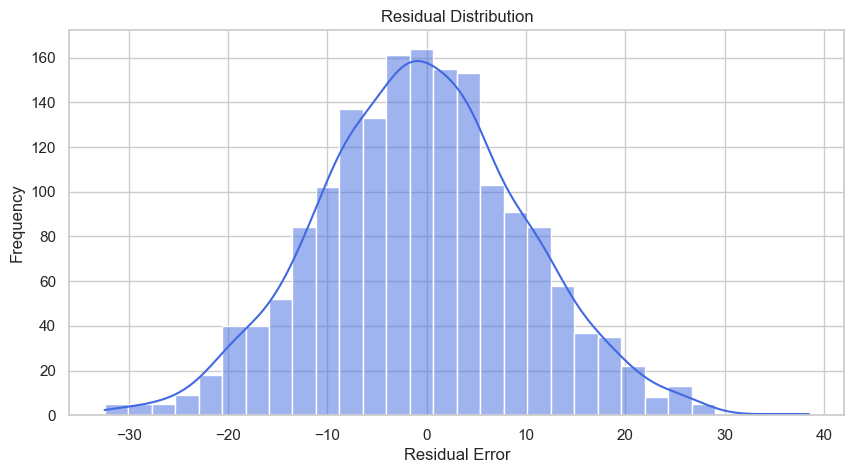

In [48]:
# ==============================================================================
# RESIDUAL DISTRIBUTION
# ==============================================================================

plt.figure(figsize=(10,5))

sns.histplot(
    residuals,
    bins=30,
    kde=True,
    color="royalblue"
)

plt.title("Residual Distribution")

plt.xlabel("Residual Error")

plt.ylabel("Frequency")

plt.show()

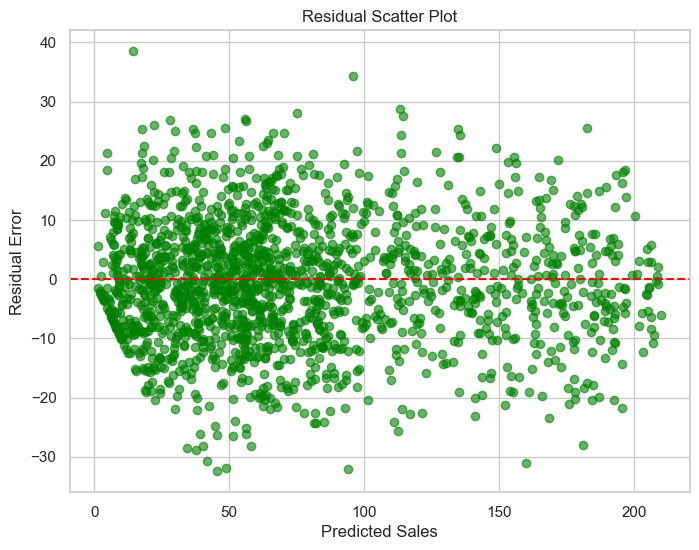

In [49]:
# ==============================================================================
# RESIDUAL SCATTER PLOT
# ==============================================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.6,
    color="green"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Sales")

plt.ylabel("Residual Error")

plt.title("Residual Scatter Plot")

plt.show()

In [51]:
# ==============================================================================
# FEATURE IMPORTANCE
# ==============================================================================

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
15,Customers,0.565221
5,Promotion,0.384246
4,Holiday,0.018600
14,Discount,0.005371
27,Discount_Amount,0.001932
8,Fuel_Price,0.001811
7,Temperature,0.001788
29,Promotion_Impact,0.001750
10,Unemployment,0.001700
26,Price_Difference,0.001688


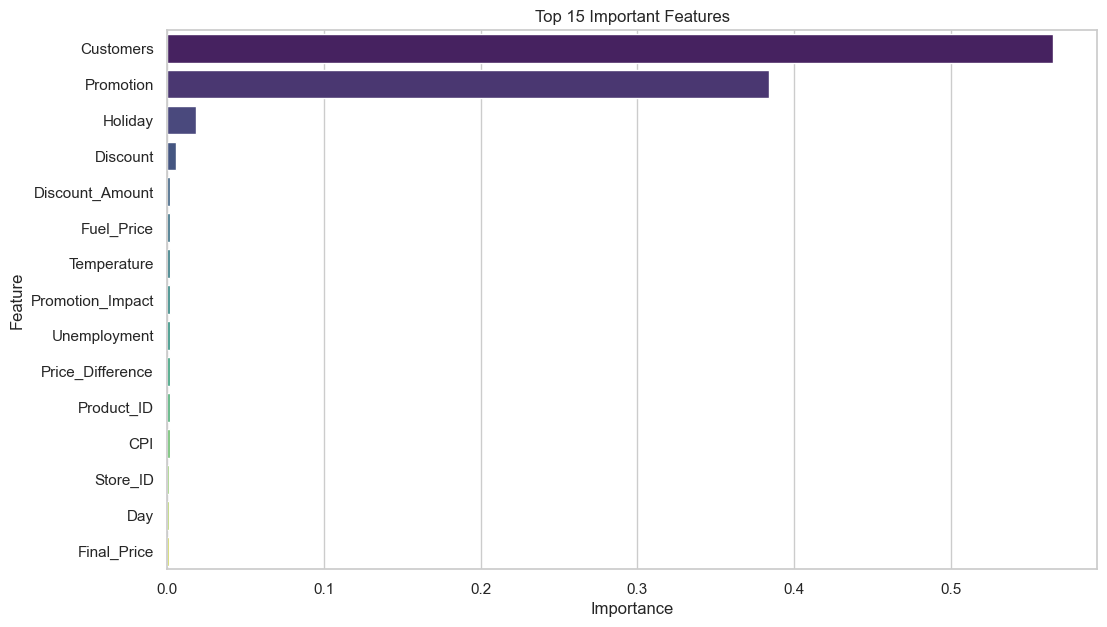

In [52]:
# ==============================================================================
# TOP 15 IMPORTANT FEATURES
# ==============================================================================

plt.figure(figsize=(12,7))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 15 Important Features")

plt.show()

In [53]:
# ==============================================================================
# FEATURE IMPORTANCE TABLE
# ==============================================================================

importance

,Feature,Importance
15,Customers,0.565221
5,Promotion,0.384246
4,Holiday,0.018600
14,Discount,0.005371
27,Discount_Amount,0.001932
8,Fuel_Price,0.001811
7,Temperature,0.001788
29,Promotion_Impact,0.001750
10,Unemployment,0.001700
26,Price_Difference,0.001688


In [54]:
# ==============================================================================
# CROSS VALIDATION
# ==============================================================================

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(

    rf_model,

    X,

    y,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

print(cv_scores)

[0.96544742 0.96382852 0.96503986 0.96425136 0.96509464]


In [55]:
# ==============================================================================
# AVERAGE CROSS VALIDATION SCORE
# ==============================================================================

print("Average CV Score :", round(cv_scores.mean(),4))

Average CV Score : 0.9647


In [56]:
# ==============================================================================
# PERFORMANCE SUMMARY
# ==============================================================================

summary = pd.DataFrame({

    "Metric":[
        "MAE",
        "MSE",
        "RMSE",
        "R²",
        "Adjusted R²",
        "MAPE",
        "Cross Validation"
    ],

    "Value":[
        mae,
        mse,
        rmse,
        test_r2,
        adjusted_r2,
        mape,
        cv_scores.mean()
    ]

})

summary

,Metric,Value
0,MAE,8.238595
1,MSE,108.111696
2,RMSE,10.397677
3,R²,0.962015
4,Adjusted R²,0.961341
5,MAPE,inf
6,Cross Validation,0.964732


In [57]:
# ==============================================================================
# SAVE RANDOM FOREST MODEL
# ==============================================================================

import os

os.makedirs("model", exist_ok=True)

joblib.dump(
    rf_model,
    "model/random_forest.pkl"
)

print("Random Forest Model Saved Successfully")

Random Forest Model Saved Successfully


In [58]:
# ==============================================================================
# SAVE PREDICTIONS
# ==============================================================================

os.makedirs("dataset", exist_ok=True)

prediction_df.to_csv(
    "dataset/random_forest_predictions.csv",
    index=False
)

print("Prediction File Saved Successfully")

Prediction File Saved Successfully


In [59]:
# ==============================================================================
# SAVE PERFORMANCE REPORT
# ==============================================================================

summary.to_csv(
    "dataset/RandomForest_Performance.csv",
    index=False
)

print("Performance Report Saved Successfully")

Performance Report Saved Successfully


In [60]:
# ==============================================================================
# VERIFY MODEL FOLDER
# ==============================================================================

import os

print(os.listdir("model"))

['decision_tree.pkl', 'label_encoder.pkl', 'linear_regression.pkl', 'linear_scaler.pkl', 'random_forest.pkl', 'scaler.pkl']


In [61]:
# ==============================================================================
# VERIFY DATASET FOLDER
# ==============================================================================

print(os.listdir("dataset"))

['DecisionTree_Performance.csv', 'decision_tree_predictions.csv', 'Linear_Regression_Performance.csv', 'linear_regression_predictions.csv', 'RandomForest_Performance.csv', 'random_forest_predictions.csv']


In [62]:
# ==============================================================================
# BUSINESS INTERPRETATION
# ==============================================================================

print("Business Interpretation")

print("- Random Forest captures complex relationships better than a single Decision Tree.")
print("- It reduces overfitting by averaging predictions from multiple trees.")
print("- Feature importance helps identify the strongest factors affecting sales.")
print("- This model is expected to outperform Linear Regression for non-linear retail data.")

Business Interpretation
- Random Forest captures complex relationships better than a single Decision Tree.
- It reduces overfitting by averaging predictions from multiple trees.
- Feature importance helps identify the strongest factors affecting sales.
- This model is expected to outperform Linear Regression for non-linear retail data.
